In [106]:
import pandas as  pd 
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
import joblib
print("All libraries imported!")

All libraries imported!


In [111]:
# Reading CSV data
df = pd.read_csv("novagen_dataset.csv")

In [112]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9549 entries, 0 to 9548
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    9549 non-null   float64
 1   BMI                    9549 non-null   float64
 2   Blood_Pressure         9549 non-null   float64
 3   Cholesterol            9549 non-null   float64
 4   Glucose_Level          9549 non-null   float64
 5   Heart_Rate             9549 non-null   float64
 6   Sleep_Hours            9549 non-null   float64
 7   Exercise_Hours         9549 non-null   float64
 8   Water_Intake           9549 non-null   float64
 9   Stress_Level           9549 non-null   float64
 10  Target                 9549 non-null   int64  
 11  Smoking                9549 non-null   int64  
 12  Alcohol                9549 non-null   int64  
 13  Diet                   9549 non-null   int64  
 14  MentalHealth           9549 non-null   int64  
 15  Phys

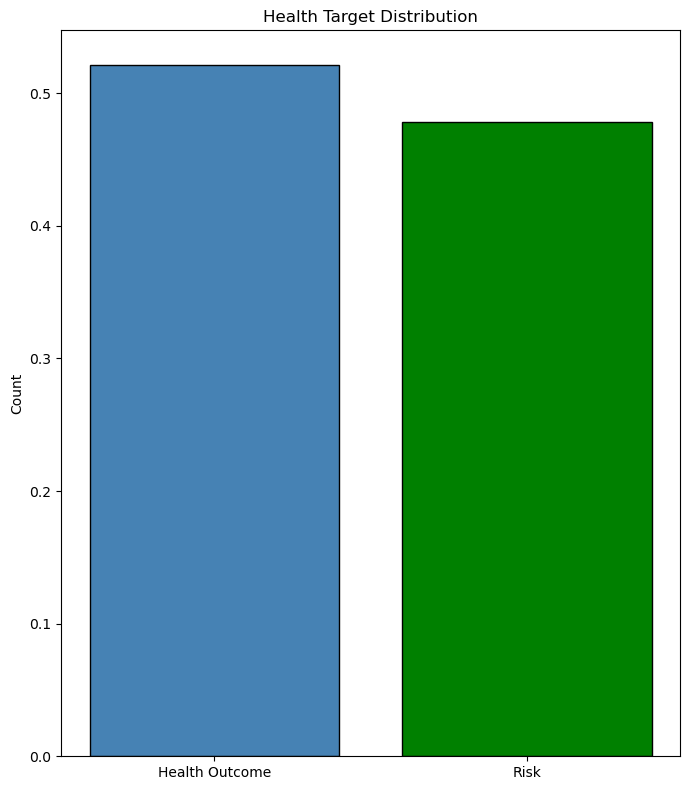

In [18]:
#  Checking Balance of targets
count = df["Target"].value_counts(normalize = True)

plt.figure(figsize = (7, 8))
plt.bar(["Health Outcome", "Risk"], count.values, color = ["steelblue", "green"], edgecolor = "black")
plt.title("Health Target Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [31]:
#  Checking how many null present
df.isnull().sum() 
# No Null value present

Age                      0
BMI                      0
Blood_Pressure           0
Cholesterol              0
Glucose_Level            0
Heart_Rate               0
Sleep_Hours              0
Exercise_Hours           0
Water_Intake             0
Stress_Level             0
Target                   0
Smoking                  0
Alcohol                  0
Diet                     0
MentalHealth             0
PhysicalActivity         0
MedicalHistory           0
Allergies                0
Diet_Type__Vegan         0
Diet_Type__Vegetarian    0
Blood_Group_AB           0
Blood_Group_B            0
Blood_Group_O            0
dtype: int64

In [22]:
X = df.drop("Target", axis = 1)
y = df["Target"]

In [30]:
# df.info()
X.head()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type__Vegan,Diet_Type__Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,2.0,26.0,111.0,198.0,99.0,72.0,4.0,1.0,5.0,5.0,...,1,2,1,0,1,False,True,True,False,False
1,8.0,24.0,121.0,199.0,103.0,75.0,2.0,1.0,2.0,9.0,...,1,2,1,2,2,False,False,True,False,False
2,81.0,27.0,147.0,203.0,100.0,74.0,10.0,-0.0,5.0,1.0,...,2,0,0,1,0,True,False,False,False,False
3,25.0,21.0,150.0,199.0,102.0,70.0,7.0,3.0,3.0,3.0,...,1,2,1,2,0,True,False,False,True,False
4,24.0,26.0,146.0,202.0,99.0,76.0,10.0,2.0,5.0,1.0,...,2,0,2,0,2,False,True,False,True,False


In [38]:
#  Feature Engineering
bool_cols = X.select_dtypes(include = "bool").columns
X[bool_cols] = X[bool_cols].astype(int)

In [39]:
X.head()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type__Vegan,Diet_Type__Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,2.0,26.0,111.0,198.0,99.0,72.0,4.0,1.0,5.0,5.0,...,1,2,1,0,1,0,1,1,0,0
1,8.0,24.0,121.0,199.0,103.0,75.0,2.0,1.0,2.0,9.0,...,1,2,1,2,2,0,0,1,0,0
2,81.0,27.0,147.0,203.0,100.0,74.0,10.0,-0.0,5.0,1.0,...,2,0,0,1,0,1,0,0,0,0
3,25.0,21.0,150.0,199.0,102.0,70.0,7.0,3.0,3.0,3.0,...,1,2,1,2,0,1,0,0,1,0
4,24.0,26.0,146.0,202.0,99.0,76.0,10.0,2.0,5.0,1.0,...,2,0,2,0,2,0,1,0,1,0


In [40]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [43]:
# Standard Scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [49]:
X_train_scaled

array([[-0.84338185, -0.33320265, -1.19568435, ..., -0.5691369 ,
        -0.58405186, -0.58042385],
       [ 1.76273016,  0.17986629, -0.01334364, ...,  1.7570465 ,
        -0.58405186, -0.58042385],
       [-1.25058685,  0.69293523,  0.66739797, ...,  1.7570465 ,
        -0.58405186, -0.58042385],
       ...,
       [-0.80266135, -0.33320265, -0.44328572, ..., -0.5691369 ,
        -0.58405186,  1.7228789 ],
       [-0.59905885,  0.69293523, -0.04917215, ..., -0.5691369 ,
        -0.58405186,  1.7228789 ],
       [-1.12842535, -0.33320265,  0.8465405 , ...,  1.7570465 ,
        -0.58405186, -0.58042385]], shape=(7639, 22))

# Train and Evaluate Base model

# Logistic Regression

In [55]:
lr_model = LogisticRegression(max_iter = 1000)
lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)

In [62]:
#  Evaluation
print("Evaluation For Logistic Regression Model\n")
print("Accuracy Score: ", accuracy_score(y_test, y_pred))
print("Precision Score: ", precision_score(y_test, y_pred))
print("Recall Score: ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))
print()
print("Classification Report :\n", classification_report(y_test, y_pred))
print()
print("Confusion Matrix\n",confusion_matrix(y_test, y_pred))

Evaluation For Logistic Regression Model

Accuracy Score:  0.8225130890052356
Precision Score:  0.8285994123408423
Recall Score:  0.8376237623762376
F1 Score:  0.8330871491875923

Classification Report :
               precision    recall  f1-score   support

           0       0.82      0.81      0.81       900
           1       0.83      0.84      0.83      1010

    accuracy                           0.82      1910
   macro avg       0.82      0.82      0.82      1910
weighted avg       0.82      0.82      0.82      1910


Confusion Matrix
 [[725 175]
 [164 846]]


# RandomForest Classifier

In [82]:
clf_model = RandomForestClassifier(n_estimators=100, max_depth = 10, min_samples_split = 5, min_samples_leaf = 2, random_state = 42)
clf_model.fit(X_train_scaled, y_train)

y_pred = clf_model.predict(X_test_scaled)
y_train_pred = clf_model.predict(X_train_scaled)

In [83]:
#  Evaluation
print("Evaluation For Random Forest Classifier Model\n")
print("Accuracy Score: ", accuracy_score(y_test, y_pred))
print("Precision Score: ", precision_score(y_test, y_pred))
print("Recall Score: ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))
print()
print("Classification Report :\n", classification_report(y_test, y_pred))
print()
print("Confusion Matrix\n",confusion_matrix(y_test, y_pred))

Evaluation For Random Forest Classifier Model

Accuracy Score:  0.9282722513089006
Precision Score:  0.9233753637245393
Recall Score:  0.9425742574257425
F1 Score:  0.932876041156296

Classification Report :
               precision    recall  f1-score   support

           0       0.93      0.91      0.92       900
           1       0.92      0.94      0.93      1010

    accuracy                           0.93      1910
   macro avg       0.93      0.93      0.93      1910
weighted avg       0.93      0.93      0.93      1910


Confusion Matrix
 [[821  79]
 [ 58 952]]


In [84]:
print("Evaluation For (y_train) Random Forest Classifier Model\n")
print("Accuracy Score: ", accuracy_score(y_train, y_train_pred))

Evaluation For (y_train) Random Forest Classifier Model

Accuracy Score:  0.9577169786621286


In [96]:
#  Cross Validation Score
scores = cross_val_score(clf_model, X_train_scaled, y_train, cv = 5, scoring = "recall")
print(scores)
print(scores.mean())
print(scores.std())

[0.95969773 0.93828715 0.94710327 0.94080605 0.95586381]
0.9483516029743886
0.008306079697406153


# Gradinet Boosting Classifier Using Grid Search CV

In [105]:
#  Cross Validation 
param_grid = {
    "n_estimators": [100,200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3,4,5]
}
classifierCV = GridSearchCV(
    gb_model,
    cv= 5,
    param_grid = param_grid,
    scoring = "recall"
)
classifierCV.fit(X_train_scaled, y_train)
print("Best Parameters:", classifierCV.best_params_)
print("Best CV Score:", classifierCV.best_score_)
y_pred = classifierCV.predict(X_test_scaled)

print("Accuracy Score: ", accuracy_score(y_test, y_pred))
print("Precision Score: ", precision_score(y_test, y_pred))
print("Recall Score: ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))
print()
print("Classification Report :\n", classification_report(y_test, y_pred))
print()
print("Confusion Matrix\n",confusion_matrix(y_test, y_pred))

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best CV Score: 0.953390656912976
Accuracy Score:  0.9465968586387434
Precision Score:  0.9503968253968254
Recall Score:  0.9485148514851485
F1 Score:  0.9494549058473737

Classification Report :
               precision    recall  f1-score   support

           0       0.94      0.94      0.94       900
           1       0.95      0.95      0.95      1010

    accuracy                           0.95      1910
   macro avg       0.95      0.95      0.95      1910
weighted avg       0.95      0.95      0.95      1910


Confusion Matrix
 [[850  50]
 [ 52 958]]


In [108]:
#  Saving the Best Model
joblib.dump(classifierCV.best_estimator_, "best_model.pkl")

['best_model.pkl']

In [110]:
# Verifying the saved model
loaded_model = joblib.load("best_model.pkl")
test_pred = loaded_model.predict(X_test_scaled)
print(test_pred)

[0 1 0 ... 1 1 1]
